# Quality control, step by step (QIQ March)
# 质量控制逐步演示（QIQ 3 月）

We load one month of BSRN station-to-archive data with :class:`~bsrn.dataset.BSRNDataset`, then walk through quality-control checks. The cells below set the file path; §2 opens it with ``BSRNDataset.from_file``.

用 :class:`~bsrn.dataset.BSRNDataset` 加载一个月度台站存档，再逐步做质量控制。下面单元设置文件路径；§2 用 ``BSRNDataset.from_file`` 打开。


## 1. File for :class:`~bsrn.dataset.BSRNDataset` / ``BSRNDataset`` 用的文件

Point ``INPUT_FILE`` at a monthly ``{ccc}{MM}{YY}.dat.gz`` archive (here QIQ March 2024). The next code cell imports ``BSRNDataset`` and prints the default column names (via the internal ``*_VAR_MAP`` helpers used by :meth:`~bsrn.dataset.BSRNDataset.data`).

将 ``INPUT_FILE`` 指向月度 ``{ccc}{MM}{YY}.dat.gz`` 存档（此处为 QIQ 2024 年 3 月）。下一代码单元导入 ``BSRNDataset`` 并打印默认列名（通过 :meth:`~bsrn.dataset.BSRNDataset.data` 使用的 ``*_VAR_MAP``）。

In [1]:
from bsrn import BSRNDataset
from bsrn.dataset import _LR0100_VAR_MAP, _LR0300_VAR_MAP, _LR4000_VAR_MAP

# Change the path here
INPUT_FILE = "/Volumes/Macintosh Research/Data/bsrn-qc/data/QIQ/qiq0324.dat.gz"

# Columns in the dataset
print("LR0100 (default):", list(_LR0100_VAR_MAP.values()))
print("LR0300 (include=['lr0300']):", list(_LR0300_VAR_MAP.values()))
print("LR4000 (include=['lr4000']):", list(_LR4000_VAR_MAP.values()))

LR0100 (default): ['ghi', 'bni', 'dhi', 'lwd', 'temp', 'rh', 'pressure']
LR0300 (include=['lr0300']): ['swu', 'lwu', 'net']
LR4000 (include=['lr4000']): ['dt1d', 'dt2d', 'dt3d', 'btd', 'dt1u', 'dt2u', 'dt3u', 'btu']


## 2. Load data / 加载数据

In [2]:
ds = BSRNDataset.from_file(INPUT_FILE)

# print metadata about the dataset
print(f"Station : {ds.station_code} ({ds.station_name})")
print(f"Lat/Lon : {ds.lat}, {ds.lon}")
print(f"Elev    : {ds.elev} m")
print(f"Res     : {ds.resolution} min")

# print the first 5 rows of the data
ds.data().head()


Station : QIQ (Qiqihar)
Lat/Lon : 47.7957, 124.4852
Elev    : 170.0 m
Res     : 1 min


,ghi,bni,dhi,lwd,temp,rh,pressure
2024-03-01 00:00:00+00:00,232.0,617.0,75.0,156.0,-9.6,34.0,995.0
2024-03-01 00:01:00+00:00,235.0,621.0,76.0,156.0,-9.6,34.0,995.0
2024-03-01 00:02:00+00:00,237.0,623.0,77.0,157.0,-9.6,34.0,995.0
2024-03-01 00:03:00+00:00,240.0,627.0,77.0,157.0,-9.5,35.0,995.0
2024-03-01 00:04:00+00:00,242.0,627.0,78.0,157.0,-9.5,35.0,995.0


## 3. Solar geometry via ``BSRNDataset.solpos`` / 用 ``solpos`` 添加太阳几何

:meth:`~bsrn.dataset.BSRNDataset.solpos` adds ``zenith``, ``bni_extra``, ``ghi_extra``, etc. to ``ds.data()`` (same frame as the radiation columns; needed before QC tests).

:meth:`~bsrn.dataset.BSRNDataset.solpos` 在 ``ds.data()`` 上增加 ``zenith``、``bni_extra``、``ghi_extra`` 等列（与辐射列同表；QC 前需要）。

In [3]:
# perform solar positioning using pydantic pipeline 
ds.solpos()

# print the first 5 rows of the data, after solpos
ds.data().head()

,ghi,bni,dhi,lwd,temp,rh,pressure,zenith,apparent_zenith,azimuth,bni_extra,ghi_extra
2024-03-01 00:00:00+00:00,232.0,617.0,75.0,156.0,-9.6,34.0,995.0,75.486,75.424,119.062,1386.239,347.414
2024-03-01 00:01:00+00:00,235.0,621.0,76.0,156.0,-9.6,34.0,995.0,75.339,75.278,119.269,1386.239,350.856
2024-03-01 00:02:00+00:00,237.0,623.0,77.0,157.0,-9.6,34.0,995.0,75.192,75.132,119.476,1386.239,354.296
2024-03-01 00:03:00+00:00,240.0,627.0,77.0,157.0,-9.5,35.0,995.0,75.046,74.986,119.683,1386.239,357.710
2024-03-01 00:04:00+00:00,242.0,627.0,78.0,157.0,-9.5,35.0,995.0,74.900,74.841,119.890,1386.239,361.121


## 4. Clear-sky modeling via ``BSRNDataset.clear_sky`` / 用 ``clear_sky`` 添加晴空辐射

:meth:`~bsrn.dataset.BSRNDataset.clear_sky` adds ``ghi_clear``, ``bni_clear``, ``dhi_clear`` columns to ``ds.data()``. Default model is Ineichen; also supports ``'mcclear'``, ``'rest2'``, ``'tj'``. The next code cell uses ``'rest2'`` as an example.

:meth:`~bsrn.dataset.BSRNDataset.clear_sky` 在 ``ds.data()`` 上增加 ``ghi_clear``、``bni_clear``、``dhi_clear`` 列。默认模型为 Ineichen；也支持 ``'mcclear'``、``'rest2'``、``'tj'``。下一代码单元以 ``'rest2'`` 为例。

In [4]:
# use REST2 model for clear-sky modeling
ds.clear_sky(model="rest2")

# print the first 5 rows of the data, after clear-sky modeling
ds.data().head()

Fetching MERRA-2 from Hugging Face: qiq/qiq0324_merra2.parquet


,ghi,bni,dhi,lwd,temp,rh,pressure,zenith,apparent_zenith,azimuth,bni_extra,ghi_extra,ghi_clear,bni_clear,dhi_clear,lwd_clear
2024-03-01 00:00:00+00:00,232.0,617.0,75.0,156.0,-9.6,34.0,995.0,75.486,75.424,119.062,1386.239,347.414,239.732694,679.617618,69.409265,163.369638
2024-03-01 00:01:00+00:00,235.0,621.0,76.0,156.0,-9.6,34.0,995.0,75.339,75.278,119.269,1386.239,350.856,242.712901,682.923829,69.865229,163.369638
2024-03-01 00:02:00+00:00,237.0,623.0,77.0,157.0,-9.6,34.0,995.0,75.192,75.132,119.476,1386.239,354.296,245.695984,686.192820,70.318309,163.369638
2024-03-01 00:03:00+00:00,240.0,627.0,77.0,157.0,-9.5,35.0,995.0,75.046,74.986,119.683,1386.239,357.710,248.661515,689.403340,70.765487,164.472390
2024-03-01 00:04:00+00:00,242.0,627.0,78.0,157.0,-9.5,35.0,995.0,74.900,74.841,119.890,1386.239,361.121,251.629675,692.578341,71.209894,164.472390


## 5. Part A — `qc` and tier row counts / A 部分 — `qc` 与各层行数

:meth:`~bsrn.dataset.BSRNDataset.qc` adds **`flag*`** columns **on the cached** :meth:`~bsrn.dataset.BSRNDataset.data` frame (in place). Count rows with **≥1 failure** in each tier from those columns (**1 = fail**). Within a tier, a row is counted **once** if any flag in that tier is 1.

:meth:`~bsrn.dataset.BSRNDataset.qc` 在缓存的 :meth:`~bsrn.dataset.BSRNDataset.data` 帧上**原地**添加 **`flag*`** 列。按各层统计「至少一项未通过」的行数（**1 = 未通过**）。同一层内任一子项为 1 则该行在该层计一次。

§7 builds the same tier-to-flag mapping in a **`TIER_COLS`** dict when comparing Part A vs Part B.

§7 在对比 A/B 时用 **`TIER_COLS`** 字典定义相同的层与 `flag*` 对应关系。


In [5]:
# run all QC tests
ds.qc()

# print the first 5 rows of the data, after QC
ds.data().head()

,ghi,bni,dhi,lwd,temp,rh,pressure,zenith,apparent_zenith,azimuth,...,flagERLLWD,flag3lowSZA,flag3highSZA,flagKKt,flagKlowSZA,flagKhighSZA,flagKbKt,flagKb,flagKt,flagTracker
2024-03-01 00:00:00+00:00,232.0,617.0,75.0,156.0,-9.6,34.0,995.0,75.486,75.424,119.062,...,0,0,0,0,0,0,0,0,0,0
2024-03-01 00:01:00+00:00,235.0,621.0,76.0,156.0,-9.6,34.0,995.0,75.339,75.278,119.269,...,0,0,0,0,0,0,0,0,0,0
2024-03-01 00:02:00+00:00,237.0,623.0,77.0,157.0,-9.6,34.0,995.0,75.192,75.132,119.476,...,0,0,0,0,0,0,0,0,0,0
2024-03-01 00:03:00+00:00,240.0,627.0,77.0,157.0,-9.5,35.0,995.0,75.046,74.986,119.683,...,0,0,0,0,0,0,0,0,0,0
2024-03-01 00:04:00+00:00,242.0,627.0,78.0,157.0,-9.5,35.0,995.0,74.900,74.841,119.890,...,0,0,0,0,0,0,0,0,0,0


## 6. Part B — Individual `*_test` functions / B 部分 — 各 `*_test` 函数

Helpers: **`n_fail`** = rows where the test **fails** (i.e. pass is False). **`n_fail_any`** = rows where **at least one** of the given pass Series is False (unique rows within that list).

辅助函数：**`n_fail`** 为失败行数；**`n_fail_any`** 为「至少一项未通过」的行数（同一行只计一次）。


In [6]:
import numpy as np
import pandas as pd
from bsrn.qc import closure, diff_ratio, erl, k_index, ppl, tracker

_qc = ds.data()


def n_fail(pass_bool):
    """Number of rows failing: *_test returns True=pass."""
    p = pass_bool if isinstance(pass_bool, pd.Series) else pd.Series(pass_bool, index=_qc.index)
    return int((~p.fillna(False)).sum())


def n_fail_any(*pass_series):
    """Rows where at least one test fails (unique rows; not sum of per-test counts)."""
    stacks = []
    for s in pass_series:
        p = s if isinstance(s, pd.Series) else pd.Series(s, index=_qc.index)
        stacks.append(p.fillna(False).to_numpy())
    all_pass = np.logical_and.reduce(stacks)
    return int((~all_pass).sum())

### 6.1 PPL (`ppl.py`)

In [7]:
pass_ghi = ppl.ghi_ppl_test(
    ghi = _qc.ghi, 
    zenith = _qc.zenith, 
    bni_extra = _qc.bni_extra
)
pass_bni = ppl.bni_ppl_test(
    bni = _qc.bni, 
    bni_extra = _qc.bni_extra
)
pass_dhi = ppl.dhi_ppl_test(
    dhi = _qc.dhi, 
    zenith = _qc.zenith, 
    bni_extra = _qc.bni_extra
)
print("PPL GHI fail rows:", n_fail(pass_ghi))
print("PPL BNI fail rows:", n_fail(pass_bni))
print("PPL DHI fail rows:", n_fail(pass_dhi))
if "lwd" in ds.data().columns:
    pass_lwd = ppl.lwd_ppl_test(_qc.lwd)
    print("PPL LWD fail rows:", n_fail(pass_lwd))
else:
    pass_lwd = None
    print("PPL LWD: (no lwd column)")
_ppl = [pass_ghi, pass_bni, pass_dhi] + ([pass_lwd] if pass_lwd is not None else [])
print("PPL tier — rows failing ≥1 subtest (unique):", n_fail_any(*_ppl))
print("(Sum of the four counts above can exceed this if the same row fails multiple PPL tests.)")

PPL GHI fail rows: 7947
PPL BNI fail rows: 6
PPL DHI fail rows: 9685
PPL LWD fail rows: 8
PPL tier — rows failing ≥1 subtest (unique): 10592
(Sum of the four counts above can exceed this if the same row fails multiple PPL tests.)


### 6.2 ERL (`erl.py`)

In [8]:
e_ghi = erl.ghi_erl_test(
    ghi = _qc.ghi, 
    zenith = _qc.zenith, 
    bni_extra = _qc.bni_extra
)
e_bni = erl.bni_erl_test(
    bni = _qc.bni, 
    zenith = _qc.zenith, 
    bni_extra = _qc.bni_extra)
e_dhi = erl.dhi_erl_test(
    dhi = _qc.dhi, 
    zenith = _qc.zenith, 
    bni_extra = _qc.bni_extra
)
print("ERL GHI fail rows:", n_fail(e_ghi))
print("ERL BNI fail rows:", n_fail(e_bni))
print("ERL DHI fail rows:", n_fail(e_dhi))
if "lwd" in ds.data().columns:
    e_lwd = erl.lwd_erl_test(_qc.lwd)
    print("ERL LWD fail rows:", n_fail(e_lwd))
else:
    e_lwd = None
_erl = [e_ghi, e_bni, e_dhi] + ([e_lwd] if e_lwd is not None else [])
print("ERL tier — rows failing ≥1 subtest (unique):", n_fail_any(*_erl))

ERL GHI fail rows: 18318
ERL BNI fail rows: 13
ERL DHI fail rows: 19271
ERL LWD fail rows: 8
ERL tier — rows failing ≥1 subtest (unique): 19353


### 6.3 Closure (`closure.py`)

In [9]:
c_low = closure.closure_low_sza_test(
    ghi = _qc.ghi, 
    bni = _qc.bni, 
    dhi = _qc.dhi, 
    zenith = _qc.zenith
)
c_high = closure.closure_high_sza_test(
    ghi = _qc.ghi, 
    bni = _qc.bni, 
    dhi = _qc.dhi, 
    zenith = _qc.zenith
)
print("Closure low-SZA  fail rows:", n_fail(c_low))
print("Closure high-SZA fail rows:", n_fail(c_high))
print("Closure tier — rows failing ≥1 subtest (unique):", n_fail_any(c_low, c_high))

Closure low-SZA  fail rows: 11
Closure high-SZA fail rows: 18
Closure tier — rows failing ≥1 subtest (unique): 29


### 6.4 Diffuse ratio (`diff_ratio.py`)

In [10]:
d_kkt = diff_ratio.k_kt_combined_test(
    ghi = _qc.ghi, 
    dhi = _qc.dhi, 
    bni_extra = _qc.bni_extra, 
    zenith = _qc.zenith
)
d_klo = diff_ratio.k_low_sza_test(
    ghi = _qc.ghi, 
    dhi = _qc.dhi, 
    zenith = _qc.zenith
)
d_khi = diff_ratio.k_high_sza_test(
    ghi = _qc.ghi, 
    dhi = _qc.dhi, 
    zenith = _qc.zenith
)
print("K–Kt combined fail rows:", n_fail(d_kkt))
print("k low-SZA       fail rows:", n_fail(d_klo))
print("k high-SZA      fail rows:", n_fail(d_khi))
print("Diffuse-ratio tier — rows failing ≥1 subtest (unique):", n_fail_any(d_kkt, d_klo, d_khi))

K–Kt combined fail rows: 20
k low-SZA       fail rows: 1
k high-SZA      fail rows: 0
Diffuse-ratio tier — rows failing ≥1 subtest (unique): 20


### 6.5 K-indices (`k_index.py`)

In [11]:
k_kbkt = k_index.kb_kt_test(
    ghi = _qc.ghi, 
    bni = _qc.bni, 
    bni_extra = _qc.bni_extra, 
    zenith = _qc.zenith
)
k_kb = k_index.kb_limit_test(
    bni = _qc.bni, 
    bni_extra = _qc.bni_extra, 
    elevation = ds.elev, 
    ghi = _qc.ghi
)
k_kt = k_index.kt_limit_test(
    ghi = _qc.ghi, 
    bni_extra = _qc.bni_extra, 
    zenith = _qc.zenith
)
print("Kb vs Kt fail rows:", n_fail(k_kbkt))
print("Kb limit   fail rows:", n_fail(k_kb))
print("Kt limit   fail rows:", n_fail(k_kt))
print("K-index tier — rows failing ≥1 subtest (unique):", n_fail_any(k_kbkt, k_kb, k_kt))

Kb vs Kt fail rows: 0
Kb limit   fail rows: 0
Kt limit   fail rows: 0
K-index tier — rows failing ≥1 subtest (unique): 0


### 6.6 Tracker (`tracker.py`)

In [12]:
pass_trk = tracker.tracker_off_test(
    ghi = _qc.ghi, 
    bni = _qc.bni, 
    zenith = _qc.zenith, 
    ghi_extra = _qc.ghi_extra, 
    ghi_clear = _qc.ghi_clear, 
    bni_clear = _qc.bni_clear
)
print("Tracker-off fail rows:", n_fail(pass_trk))

Tracker-off fail rows: 351


## 7. Compare Part A vs Part B (per tier) / 对比 A 与 B（按层）

**Part A** uses **`qc`** `flag*` columns (tier groupings as in §5). **Part B** uses raw `*_test` pass/fail booleans and **`n_fail_any`** (tier unique fail rows from §6), including **`pass_trk`** from §6.6. Run §5 (so `flag*` exist), then §6 through §6.6, before this cell. Counts should **match** for each tier.

**A 部分** 为 **`qc`** 的 `flag*`（分层与 §5 一致）；**B 部分** 为 §6 中原始 `*_test` 与 **`n_fail_any`** 的按层失败行数（含 §6.6 的 **`pass_trk`**）。请先运行 §5（写入 `flag*`），再运行 §6 至 §6.6。各层计数应**一致**。


In [13]:
TIER_COLS = {
    "PPL": [c for c in _qc.columns if c.startswith("flagPPL")],
    "ERL": [c for c in _qc.columns if c.startswith("flagERL")],
    "Closure": [c for c in _qc.columns if c.startswith("flag3")],
    "Diffuse k / K–Kt": ["flagKKt", "flagKlowSZA", "flagKhighSZA"],
    "K-indices": ["flagKbKt", "flagKb", "flagKt"],
    "Tracker": ["flagTracker"],
}
part_a_tier = {}
for name, want in TIER_COLS.items():
    cols = [c for c in want if c in _qc.columns]
    if cols:
        part_a_tier[name] = int(_qc[cols].eq(1).any(axis=1).sum())

part_b_tier = {
    "PPL": n_fail_any(*_ppl),
    "ERL": n_fail_any(*_erl),
    "Closure": n_fail_any(c_low, c_high),
    "Diffuse k / K–Kt": n_fail_any(d_kkt, d_klo, d_khi),
    "K-indices": n_fail_any(k_kbkt, k_kb, k_kt),
    "Tracker": n_fail(pass_trk),
}

cmp = pd.DataFrame(
    {
        "Part A (qc flag*, any fail in tier)": pd.Series(part_a_tier),
        "Part B (raw *_test, tier unique fails)": pd.Series(part_b_tier),
    }
)
cmp["match"] = cmp.iloc[:, 0] == cmp.iloc[:, 1]
cmp

,"Part A (qc flag*, any fail in tier)","Part B (raw *_test, tier unique fails)",match
PPL,10592,10592,True
ERL,19353,19353,True
Closure,29,29,True
Diffuse k / K–Kt,20,20,True
K-indices,0,0,True
Tracker,351,351,True


## 8. Daily QC audit table / 日尺度 QC 审计表

**``ds.plot.table()``** (via :attr:`~bsrn.dataset.BSRNDataset.plot`) calls **`get_daily_stats`** on ``ds.data()`` then **`plot_qc_table`**: **one row per calendar day** with sunshine-duration metrics (**SD**), per-component **PPL / ERL** failure **minute counts**, and composite rows (**closure**, **diffuse ratio**, **K-index**, **tracker**). The figure is a **heatmap-style table** (Wong palette: passes white, stats sky blue, tier failures by level). 

**``ds.plot.table()``**（经 :attr:`~bsrn.dataset.BSRNDataset.plot`）对 ``ds.data()`` 调用 **`get_daily_stats`** 再 **`plot_qc_table`**：按**日**一行，含 **SD**、各分量 **PPL/ERL** 失败**分钟数**、以及 **closure / diffuse ratio / K-index / tracker** 合成行；**类表格热图**（Wong 色）。

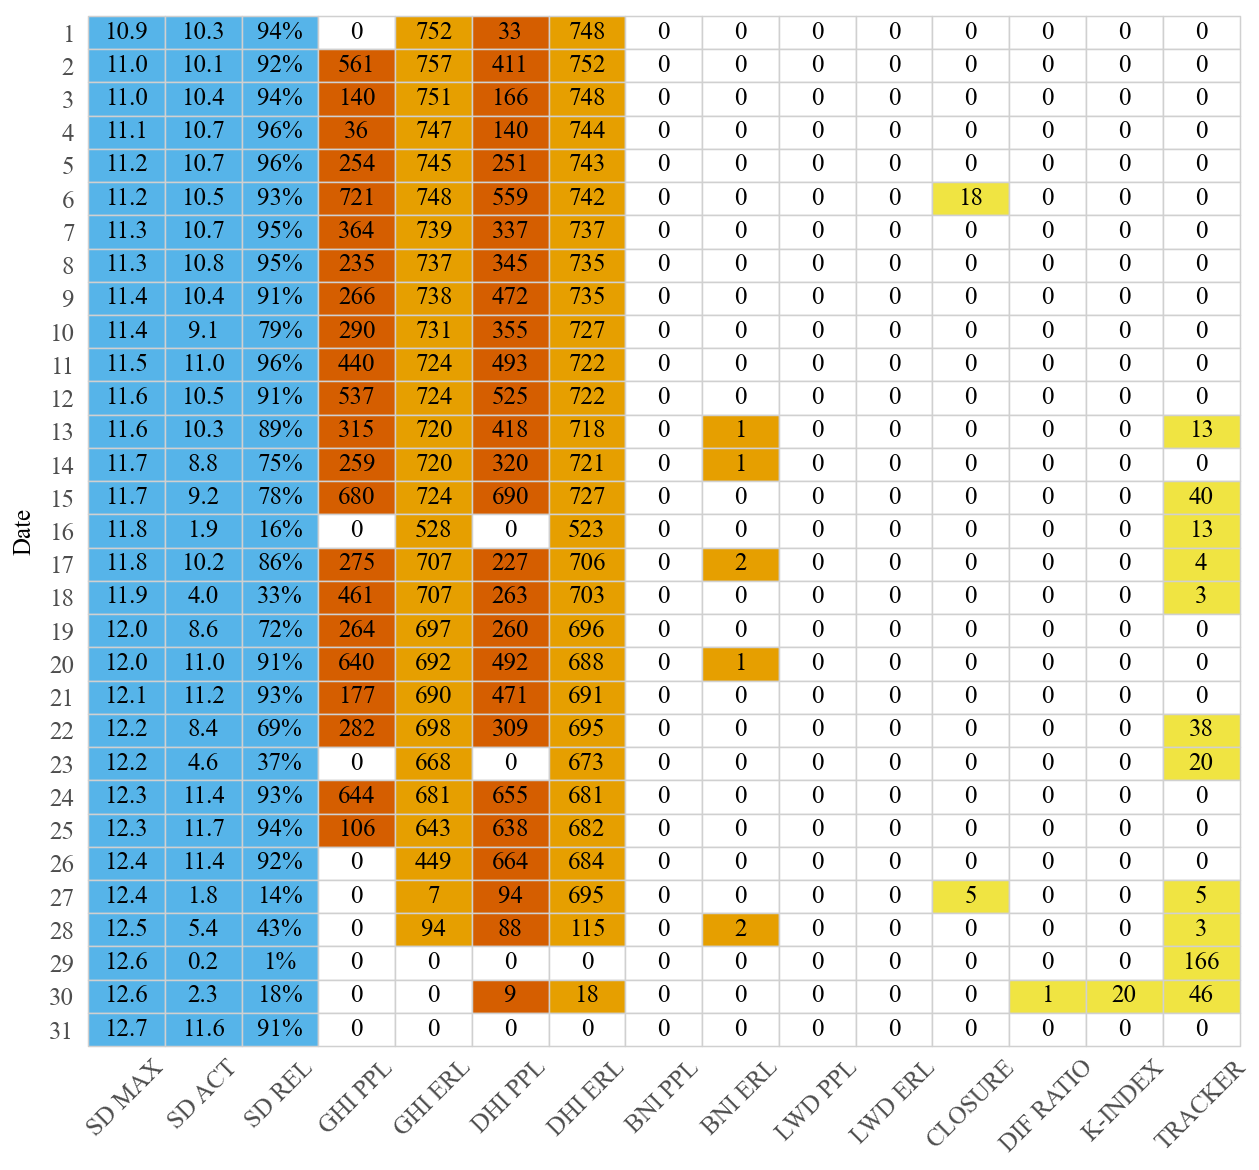

In [14]:
ds.plot.table()

## 9. Faceted timeseries for 27 March (UTC) / 3 月 27 日分面时间序列

**``ds.plot.daily(...)``** (via :attr:`~bsrn.dataset.BSRNDataset.plot`) calls **`plot_bsrn_timeseries_day`** with **`df=ds.data()`** and **`station_code=ds.station_code`**: standard **3×3** facets (GHI/BNI/DHI/LWD, diagnostics, met) for **one UTC calendar day** from the **cached** monthly frame. The helper recomputes solar geometry and, when ``station_code`` is set, adds **default Ineichen** clear-sky lines for the figure (measured series still come from ``ds.data()``). **Level 1–6 QC failure markers** (Wong colours) use ``run_qc`` inside the plot path. Low-level API: ``bsrn.visualization.timeseries.plot_bsrn_timeseries_day`` (pass ``file_path`` and omit ``df`` to load from disk instead).

**``ds.plot.daily(...)``**（经 :attr:`~bsrn.dataset.BSRNDataset.plot`）以 **`df=ds.data()`**、**`station_code=ds.station_code`** 调用 **`plot_bsrn_timeseries_day`**：从**缓存**月数据截取 **UTC** **某日**，**3×3** 分面（辐照、诊断、气象）。内部重算太阳几何；有 ``station_code`` 时为图内晴空线追加**默认 Ineichen**（实测曲线仍来自 ``ds.data()``）。**1–6 级 QC 失败标记**在绘图路径内通过 ``run_qc`` 生成。底层 API：``bsrn.visualization.timeseries.plot_bsrn_timeseries_day``（也可只传 ``file_path``、不传 ``df`` 从磁盘加载）。

March **27** is the day highlighted elsewhere for **tracker** issues; adjust **`DAY_UTC`** to explore other days.

3 月 **27** 日为与跟踪器问题相关的示例日；可改 **`DAY_UTC`** 查看其他日。

/Volumes/Macintosh Research/Data/bsrn-qc/src/bsrn/visualization/daily.py:162: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.


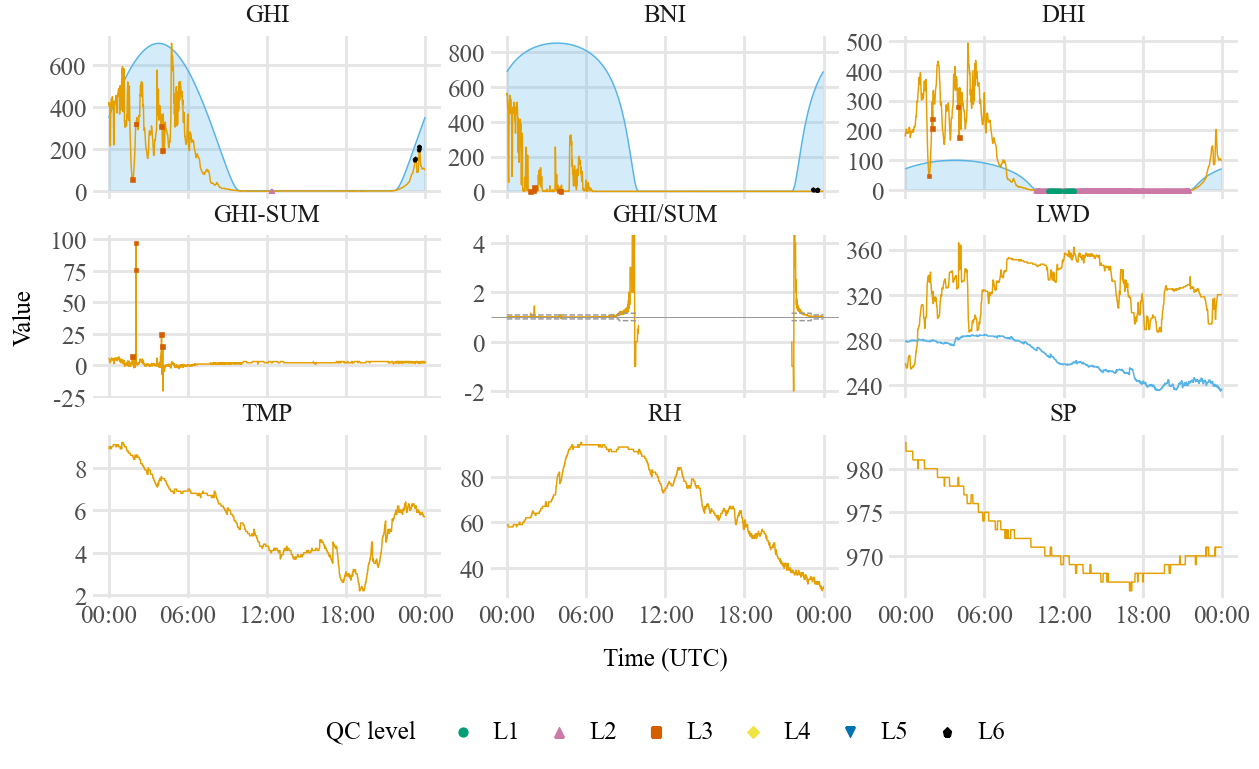

In [15]:
DAY_UTC = "2024-03-27"

# plot_bsrn_timeseries_day(..., df=ds.data(), station_code=ds.station_code)
ds.plot.daily(DAY_UTC)

# Optional: output_file="qiq_2024-03-27.pdf", title="...", apply_qc=True, show_qc_markers=True